In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "fiverr_gigs_cleaned.csv"
MODELS_PATH = ROOT / "models"
REPORTS_PATH = ROOT / "reports"
FIGURES_PATH = REPORTS_PATH / "figures"

MODELS_PATH.mkdir(exist_ok=True)
REPORTS_PATH.mkdir(exist_ok=True)
FIGURES_PATH.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
display(df.head())

(1259, 15)


,gig_title,gig_url,rating_raw,seller_level_raw,price_raw,rating,review_count,price_pkr,seller_level,title_clean,title_word_count,seller_username,listing_position,log_price_pkr,log_review_count
0,"I will do excel formulas, vba macros, charts, ...",https://www.fiverr.com/maltehar/do-excel-formu...,5.0(56),Level 2 Seller,"PKR 8,701",5.0,56.0,8701,Level 2 Seller,i will do excel formulas vba macros charts for...,10,maltehar,1,9.071308,4.043051
1,"I will do data mining, web scraping, data extr...",https://www.fiverr.com/hotopilams/do-data-mini...,5.0(1k+),Top Rated Seller,"PKR 3,263",5.0,1000.0,3263,Top Rated Seller,i will do data mining web scraping data extrac...,12,hotopilams,2,8.090709,6.908755
2,"I will do web scraping , data scraping, scrapi...",https://www.fiverr.com/kodweb/do-web-scraping-...,5.0(63),Level 2 Seller,"PKR 2,176",5.0,63.0,2176,Level 2 Seller,i will do web scraping data scraping scraping ...,11,kodweb,3,7.685703,4.158883
3,"I will do python web scraping , data entry , a...",https://www.fiverr.com/asad__haadi/do-web-scra...,5.0(266),Level 2 Seller,"PKR 1,088",5.0,266.0,1088,Level 2 Seller,i will do python web scraping data entry and d...,11,asad__haadi,4,6.993015,5.587249
4,I will data scraping web site scraping and dat...,https://www.fiverr.com/yourbuddy/web-scraping-...,4.9(275),Level 2 Seller,"PKR 4,351",4.9,275.0,4351,Level 2 Seller,i will data scraping web site scraping and dat...,10,yourbuddy,5,8.378391,5.620401


In [3]:
feature_columns = [
    "title_clean",
    "price_pkr",
    "seller_level",
    "title_word_count",
]

model_df = df.dropna(
    subset=["review_count"]
).copy()

X = model_df[feature_columns]
y_original = model_df["review_count"].astype(float)
y_log = np.log1p(y_original)

print("Jumlah data supervised:", len(model_df))
print("Fitur:", feature_columns)

Jumlah data supervised: 629
Fitur: ['title_clean', 'price_pkr', 'seller_level', 'title_word_count']


In [4]:
X_train_validation, X_test, y_train_validation, y_test = train_test_split(
    X,
    y_log,
    test_size=0.15,
    random_state=42,
)

validation_ratio = 0.15 / 0.85

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_validation,
    y_train_validation,
    test_size=validation_ratio,
    random_state=42,
)

print("Train      :", X_train.shape)
print("Validation :", X_validation.shape)
print("Test       :", X_test.shape)

Train      : (439, 4)
Validation : (95, 4)
Test       : (95, 4)


In [5]:
text_feature = "title_clean"

numeric_features = [
    "price_pkr",
    "title_word_count",
]

categorical_features = [
    "seller_level",
]

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(with_mean=False),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=1500,
            ),
            text_feature,
        ),
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "category",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

In [7]:
def evaluate_regression(
    model,
    X_data,
    y_log_data,
):
    prediction_log = model.predict(X_data)

    actual_reviews = np.expm1(y_log_data)
    predicted_reviews = np.expm1(prediction_log)

    predicted_reviews = np.clip(
        predicted_reviews,
        0,
        None,
    )

    mae = mean_absolute_error(
        actual_reviews,
        predicted_reviews,
    )

    mse = mean_squared_error(
        actual_reviews,
        predicted_reviews,
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        actual_reviews,
        predicted_reviews,
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
    }, predicted_reviews

In [8]:
dummy_model = DummyRegressor(
    strategy="median"
)

dummy_model.fit(
    np.zeros((len(y_train), 1)),
    y_train,
)

dummy_prediction_log = dummy_model.predict(
    np.zeros((len(y_validation), 1))
)

dummy_actual = np.expm1(y_validation)
dummy_prediction = np.clip(
    np.expm1(dummy_prediction_log),
    0,
    None,
)

dummy_metrics = {
    "Model": "Dummy Baseline",
    "MAE": mean_absolute_error(
        dummy_actual,
        dummy_prediction,
    ),
    "MSE": mean_squared_error(
        dummy_actual,
        dummy_prediction,
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            dummy_actual,
            dummy_prediction,
        )
    ),
    "R2": r2_score(
        dummy_actual,
        dummy_prediction,
    ),
}

dummy_metrics

{'Model': 'Dummy Baseline',
 'MAE': 61.65263157894737,
 'MSE': 20885.694736842106,
 'RMSE': np.float64(144.51883869185397),
 'R2': -0.14920571616540879}

In [9]:
ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            Ridge(
                solver="lsqr",
            ),
        ),
    ]
)

ridge_parameters = {
    "model__alpha": [
        0.01,
        0.1,
        1.0,
        10.0,
        50.0,
        100.0,
    ],
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_parameters,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

ridge_search.fit(
    X_train,
    y_train,
)

print("Parameter terbaik Ridge:")
print(ridge_search.best_params_)

ridge_metrics, ridge_validation_prediction = evaluate_regression(
    ridge_search.best_estimator_,
    X_validation,
    y_validation,
)

ridge_metrics

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Parameter terbaik Ridge:
{'model__alpha': 1.0}


{'MAE': 50.58568070092404,
 'MSE': 11643.553741608055,
 'RMSE': np.float64(107.9052998772908),
 'R2': 0.3593299775309138}

In [10]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                tree_method="hist",
                n_jobs=1,
            ),
        ),
    ]
)

xgb_parameters = {
    "model__n_estimators": [
        100,
        200,
        300,
        500,
    ],
    "model__max_depth": [
        2,
        3,
        4,
        5,
    ],
    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
    ],
    "model__subsample": [
        0.7,
        0.85,
        1.0,
    ],
    "model__colsample_bytree": [
        0.7,
        0.85,
        1.0,
    ],
    "model__reg_alpha": [
        0,
        0.1,
        1.0,
    ],
    "model__reg_lambda": [
        1.0,
        5.0,
        10.0,
    ],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_parameters,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(
    X_train,
    y_train,
)

print("Parameter terbaik XGBoost:")
print(xgb_search.best_params_)

xgb_metrics, xgb_validation_prediction = evaluate_regression(
    xgb_search.best_estimator_,
    X_validation,
    y_validation,
)

xgb_metrics

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Parameter terbaik XGBoost:
{'model__subsample': 0.85, 'model__reg_lambda': 1.0, 'model__reg_alpha': 1.0, 'model__n_estimators': 500, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}


{'MAE': 49.53139703399257,
 'MSE': 12095.911947313487,
 'RMSE': np.float64(109.98141637255581),
 'R2': 0.33443960915671755}

,Model,MAE,MSE,RMSE,R2
1,Ridge Regression,50.585681,11643.553742,107.905300,0.359330
2,XGBoost Regressor,49.531397,12095.911947,109.981416,0.334440
0,Dummy Baseline,61.652632,20885.694737,144.518839,-0.149206


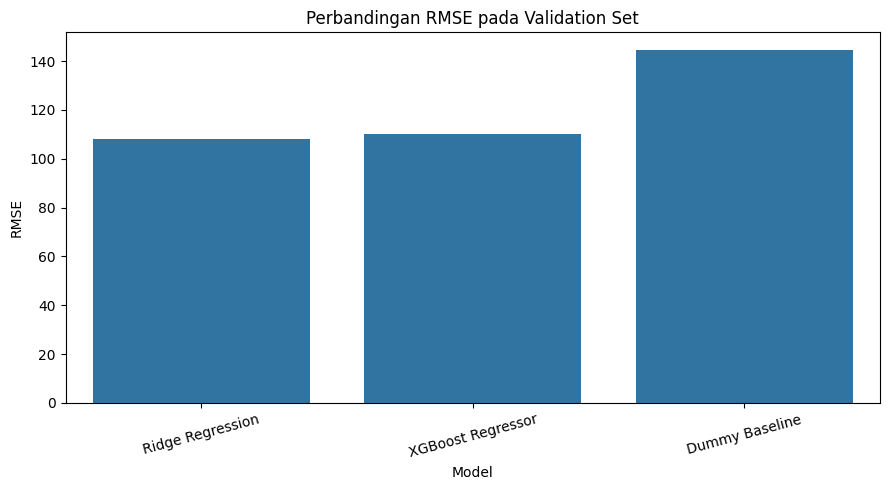

In [11]:
comparison = pd.DataFrame(
    [
        dummy_metrics,
        {
            "Model": "Ridge Regression",
            **ridge_metrics,
        },
        {
            "Model": "XGBoost Regressor",
            **xgb_metrics,
        },
    ]
).sort_values(
    "RMSE"
)

display(comparison)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE",
)

plt.title("Perbandingan RMSE pada Validation Set")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "07_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [12]:
candidate_models = {
    "Ridge Regression": ridge_search.best_estimator_,
    "XGBoost Regressor": xgb_search.best_estimator_,
}

candidate_rmse = {
    "Ridge Regression": ridge_metrics["RMSE"],
    "XGBoost Regressor": xgb_metrics["RMSE"],
}

best_model_name = min(
    candidate_rmse,
    key=candidate_rmse.get,
)

selected_model = candidate_models[
    best_model_name
]

print("Model terpilih:", best_model_name)

Model terpilih: Ridge Regression


In [13]:
X_final_train = pd.concat(
    [
        X_train,
        X_validation,
    ],
    axis=0,
)

y_final_train = pd.concat(
    [
        y_train,
        y_validation,
    ],
    axis=0,
)

final_model = clone(
    selected_model
)

final_model.fit(
    X_final_train,
    y_final_train,
)

print("Model final berhasil dilatih.")

Model final berhasil dilatih.


In [14]:
test_metrics, test_prediction = evaluate_regression(
    final_model,
    X_test,
    y_test,
)

final_test_metrics = pd.DataFrame(
    [
        {
            "Model": best_model_name,
            **test_metrics,
        }
    ]
)

display(final_test_metrics)

comparison.to_csv(
    REPORTS_PATH / "model_metrics_validation.csv",
    index=False,
)

final_test_metrics.to_csv(
    REPORTS_PATH / "model_metrics_test.csv",
    index=False,
)

,Model,MAE,MSE,RMSE,R2
0,Ridge Regression,65.533792,36511.863363,191.080777,0.165166


,title_clean,price_pkr,seller_level,title_word_count,actual_review,predicted_review,residual
1120,i will do data analytics and modelling with rs...,10876,Level 1 Seller,9,32.0,5.664387,26.335613
257,i will assist in engineering economics problems,4351,Unknown,7,2.0,1.951117,0.048883
1177,i will do data science using python or r,2176,Level 1 Seller,9,25.0,12.807473,12.192527
218,i will create machine learning models for pred...,10876,Level 2 Seller,9,1.0,25.795179,-24.795179
1158,i will do data analysis and machine learning u...,17401,Level 2 Seller,11,82.0,84.747504,-2.747504


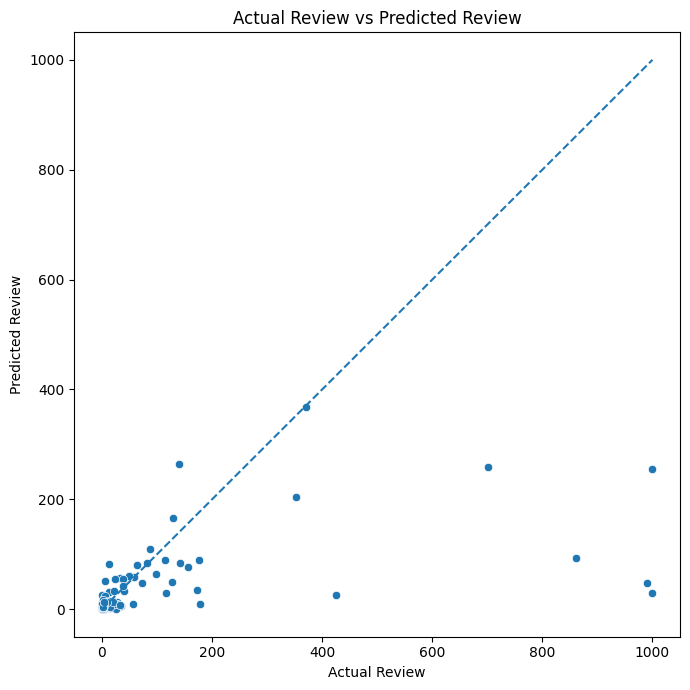

In [15]:
test_actual = np.expm1(y_test)

test_results = X_test.copy()

test_results["actual_review"] = (
    test_actual.values
)

test_results["predicted_review"] = (
    test_prediction
)

test_results["residual"] = (
    test_results["actual_review"]
    - test_results["predicted_review"]
)

display(test_results.head())

plt.figure(figsize=(7, 7))

sns.scatterplot(
    data=test_results,
    x="actual_review",
    y="predicted_review",
)

max_value = max(
    test_results["actual_review"].max(),
    test_results["predicted_review"].max(),
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
)

plt.title("Actual Review vs Predicted Review")
plt.xlabel("Actual Review")
plt.ylabel("Predicted Review")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "08_actual_vs_prediction.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

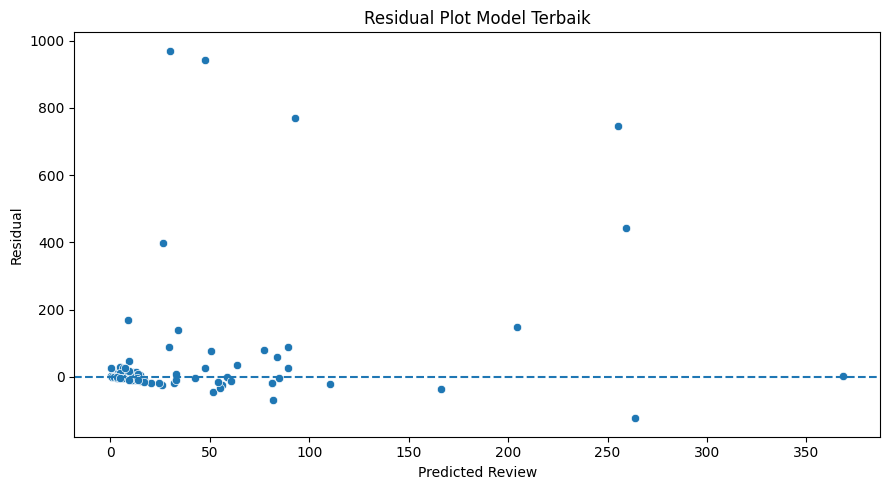

In [16]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=test_results,
    x="predicted_review",
    y="residual",
)

plt.axhline(
    0,
    linestyle="--",
)

plt.title("Residual Plot Model Terbaik")
plt.xlabel("Predicted Review")
plt.ylabel("Residual")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "09_residual_plot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

test_results.to_csv(
    REPORTS_PATH / "test_predictions.csv",
    index=False,
)

In [17]:
MODEL_PATH = (
    MODELS_PATH
    / "best_demand_model.joblib"
)

joblib.dump(
    final_model,
    MODEL_PATH,
)

print("Model disimpan:", MODEL_PATH)

loaded_model = joblib.load(
    MODEL_PATH
)

sample_prediction = loaded_model.predict(
    X_test.head(3)
)

print(np.expm1(sample_prediction))

Model disimpan: c:\Users\USER\Downloads\fiverr-market-gap\models\best_demand_model.joblib
[ 5.66438744  1.95111685 12.80747345]


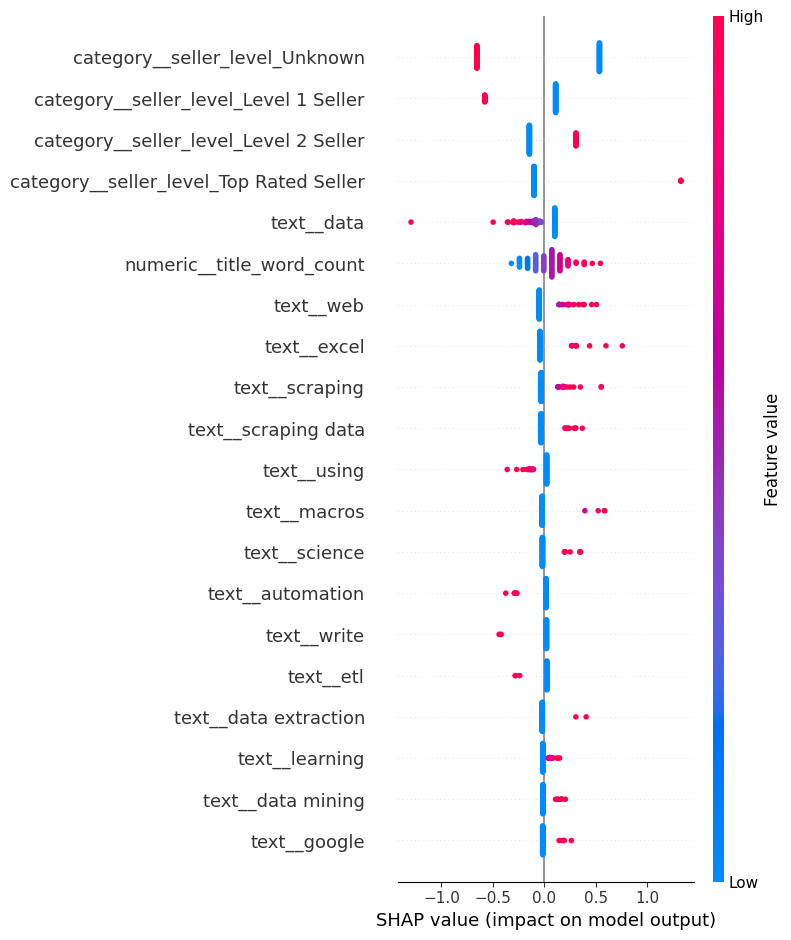

In [18]:
import shap

final_preprocessor = (
    final_model.named_steps[
        "preprocessor"
    ]
)

final_estimator = (
    final_model.named_steps[
        "model"
    ]
)

X_shap_sample = X_test.sample(
    n=min(100, len(X_test)),
    random_state=42,
)

X_shap_transformed = (
    final_preprocessor.transform(
        X_shap_sample
    )
)

feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

if hasattr(
    X_shap_transformed,
    "toarray",
):
    X_shap_dense = (
        X_shap_transformed.toarray()
    )
else:
    X_shap_dense = X_shap_transformed

if best_model_name == "XGBoost Regressor":
    explainer = shap.TreeExplainer(
        final_estimator
    )

    shap_values = explainer.shap_values(
        X_shap_dense
    )

else:
    X_background = (
        final_preprocessor.transform(
            X_final_train.sample(
                n=min(100, len(X_final_train)),
                random_state=42,
            )
        )
    )

    if hasattr(X_background, "toarray"):
        X_background = X_background.toarray()

    explainer = shap.LinearExplainer(
        final_estimator,
        X_background,
    )

    shap_values = explainer.shap_values(
        X_shap_dense
    )

    shap.summary_plot(
    shap_values,
    X_shap_dense,
    feature_names=feature_names,
    max_display=20,
    show=False,
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "10_shap_summary.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()